# Grupo 4 — Random Forest para temperatura em Jena

Previsão causal da temperatura média da próxima hora. Dados, treino, busca, gráficos e métricas aparecem neste notebook; a execução não grava arquivos de resultados. As saídas exibidas foram migradas da execução de 30/09/2026 e serão atualizadas ao rodar as células novamente.


### Informações do Grupo

##### Grupo: 4

Base: `jena_climate_2009_2016.csv`

Previsão da temperatura do ar na base Jena Climate.

- Granularidade: `horária` (agregação da base original de 10 minutos)
- Variável-alvo: `T (degC)`
- Random State (seed): `42`
- Treino-teste: `80% / 20%`, respeitando a ordem temporal

## Importações e Configurações Padrão 

In [1]:
from pathlib import Path
import os
import sys
import time
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import ParameterSampler
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

PROJECT_ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
                    if (p / 'preparacao_bases.py').is_file())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
from funcoes_series_temporais import analisar_componente_residual, calcular_forca_sazonalidade

In [2]:
BASE_NAME = 'clima'
HORIZON = 1
SEASONAL_PERIOD = 24
MODEL_EXOG_COLUMNS = ['p (mbar)', 'rh (%)', 'wv (m/s)', 'wd_sin', 'wd_cos']
SEED = 42
N_JOBS = min(6, os.cpu_count() or 1)

## Configuração do Random Forest

In [ ]:
TARGET_LAGS = [1, 2, 3, 6, 12, 24, 48, 168]
EXOG_COLUMNS = MODEL_EXOG_COLUMNS
EXOG_LAGS = {coluna: [1, 24] for coluna in EXOG_COLUMNS}
ROLLING_WINDOWS = [6, 24, 168]
PARAM_GRID = {
    'n_estimators': [100, 200],
    'max_depth': [10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2, 5],
    'max_features': ['sqrt', 1.0],
}
N_CANDIDATOS = 12
N_SPLITS_VALIDACAO = 3
MESES_VALIDACAO = 6

# 1. Preparação da base

## T01 — Base tratada

Limpeza e agregação são executados em `preparar-bases.ipynb`. Aqui é lido o Excel publicado, com o mesmo corte temporal para todos os modelos. Lags são criados antes de excluir exemplos com valores ausentes.

In [4]:
# T01: consome exclusivamente o Excel tratado e verifica sua integridade.
from preparacao_bases import carregar_base_tratada

df, metadados_base = carregar_base_tratada(BASE_NAME, PROJECT_ROOT)
TARGET_COLUMN = metadados_base['alvo']
FREQUENCY = metadados_base['frequencia']
TRAIN_RATIO = metadados_base['treino']
SEED = metadados_base['seed']
FIM_TREINO = pd.Timestamp(metadados_base['fim_treino'])
INICIO_TESTE = pd.Timestamp(metadados_base['inicio_teste'])
np.random.seed(SEED)
diagnostico_base = pd.DataFrame([{
    'base': BASE_NAME, 'linhas': len(df), 'alvos_ausentes': int(df[TARGET_COLUMN].isna().sum()),
    'fim_treino': FIM_TREINO, 'inicio_teste': INICIO_TESTE, 'seed': SEED,
}])
display(diagnostico_base)

,base,linhas,alvos_ausentes,fim_treino,inicio_teste,seed
0,clima,70129,88,2015-05-27 14:00:00,2015-05-27 15:00:00,42


## T02 — Dicionário de dados e disponibilidade temporal

Criação do dicionário de dados e análise de disponibilidade temporal das variáveis exógenas para prevenir data leakage.

In [5]:
# Dicionário e disponibilidade temporal das variáveis
DICIONARIO = pd.DataFrame([
    {"variavel": coluna, "tipo": str(df[coluna].dtype),
     "disponibilidade": "observada; usada apenas com defasagens",
     "min": df[coluna].min(), "max": df[coluna].max(), "media": df[coluna].mean()}
    for coluna in [TARGET_COLUMN] + EXOG_COLUMNS
])
display(DICIONARIO.round(3))

,variavel,tipo,disponibilidade,min,max,media
0,T (degC),float64,observada; usada apenas com defasagens,-22.653,37.038,9.442
1,p (mbar),float64,observada; usada apenas com defasagens,934.905,1015.243,989.214
2,rh (%),float64,observada; usada apenas com defasagens,13.683,100.000,76.029
3,wv (m/s),float64,observada; usada apenas com defasagens,0.000,12.895,2.129
4,wd_sin,float64,observada; usada apenas com defasagens,-0.999,0.999,-0.168
5,wd_cos,float64,observada; usada apenas com defasagens,-1.000,1.000,-0.288


## T03 — Análise exploratória visual

Análise visual do alvo e das variáveis exógenas, diagnóstico de outliers e registro das decisões de limpeza.

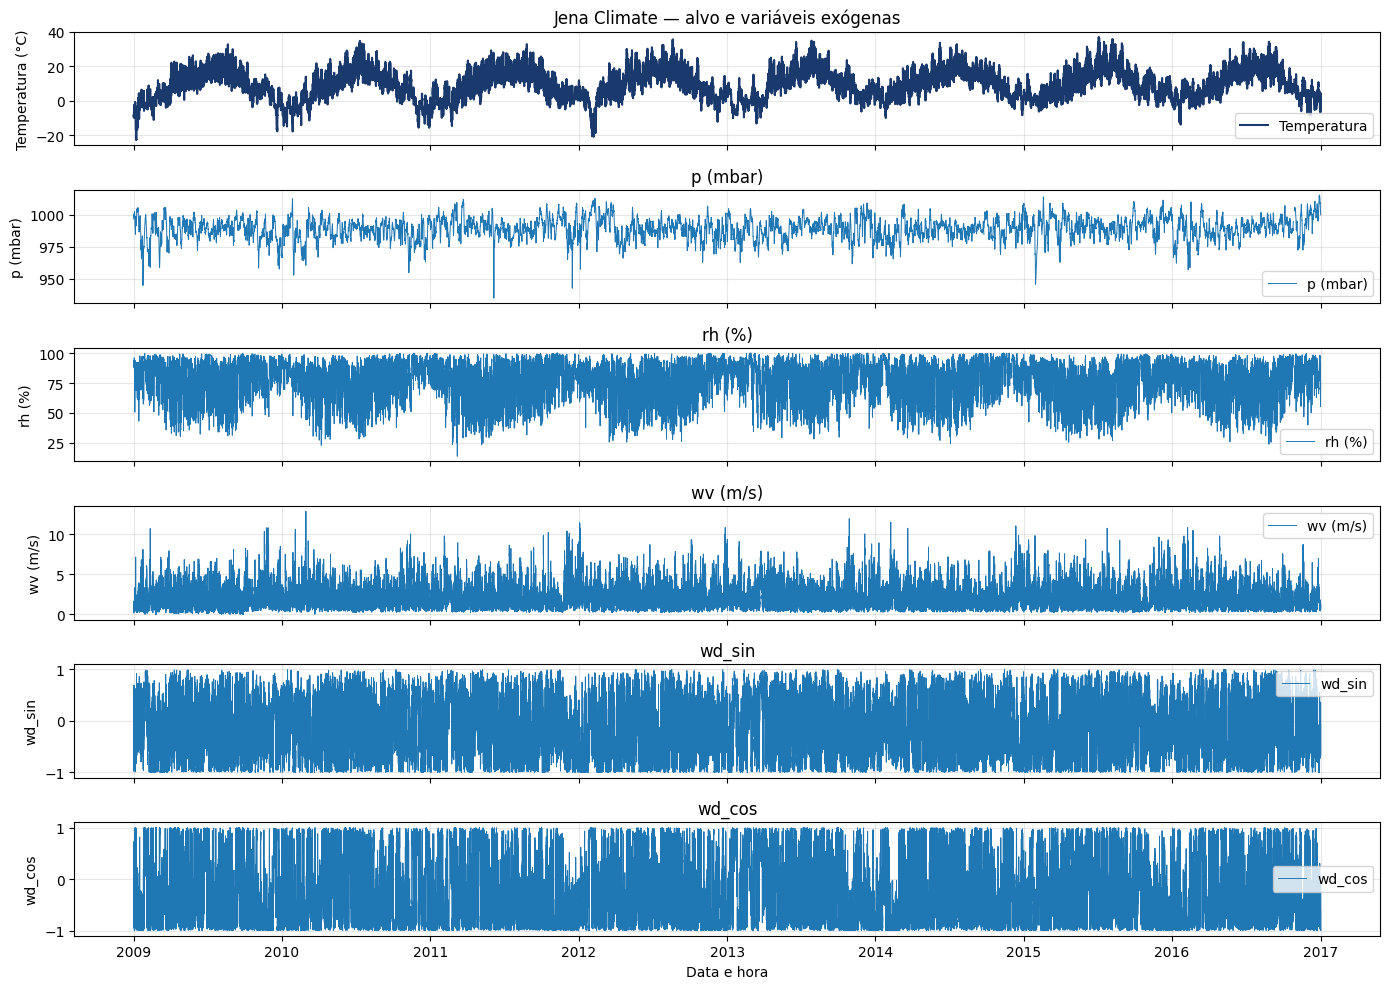

In [6]:
# Análise exploratória visual
fig, axes = plt.subplots(len(EXOG_COLUMNS) + 1, 1, figsize=(14, 10), sharex=True, squeeze=False)
axes = axes[:, 0]
axes[0].plot(df.index, df[TARGET_COLUMN], color="#1a3a6e", label="Temperatura")
axes[0].set_title("Jena Climate — alvo e variáveis exógenas")
axes[0].set_ylabel("Temperatura (°C)")
axes[0].legend(); axes[0].grid(alpha=0.3)
for ax, coluna in zip(axes[1:], EXOG_COLUMNS):
    ax.plot(df.index, df[coluna], linewidth=0.7, label=coluna)
    ax.set_title(coluna); ax.set_ylabel(coluna); ax.legend(); ax.grid(alpha=0.3)
axes[-1].set_xlabel("Data e hora")
plt.tight_layout(); plt.show()

# 2. Sazonalidade

## T04 — Decomposição STL

Diagnóstico do ciclo diário (`period=24`) no maior trecho horário contínuo e observado do treino. As lacunas não são comprimidas. A tendência pode conter variação anual; a STL não alimenta o Random Forest nem a escolha de features após ver o teste.

STL no treino: 2009-01-01 00:00:00 a 2014-09-24 17:00:00 (50,226 horas)


Força sazonal diária: 0.6929
Força de tendência: 0.9595


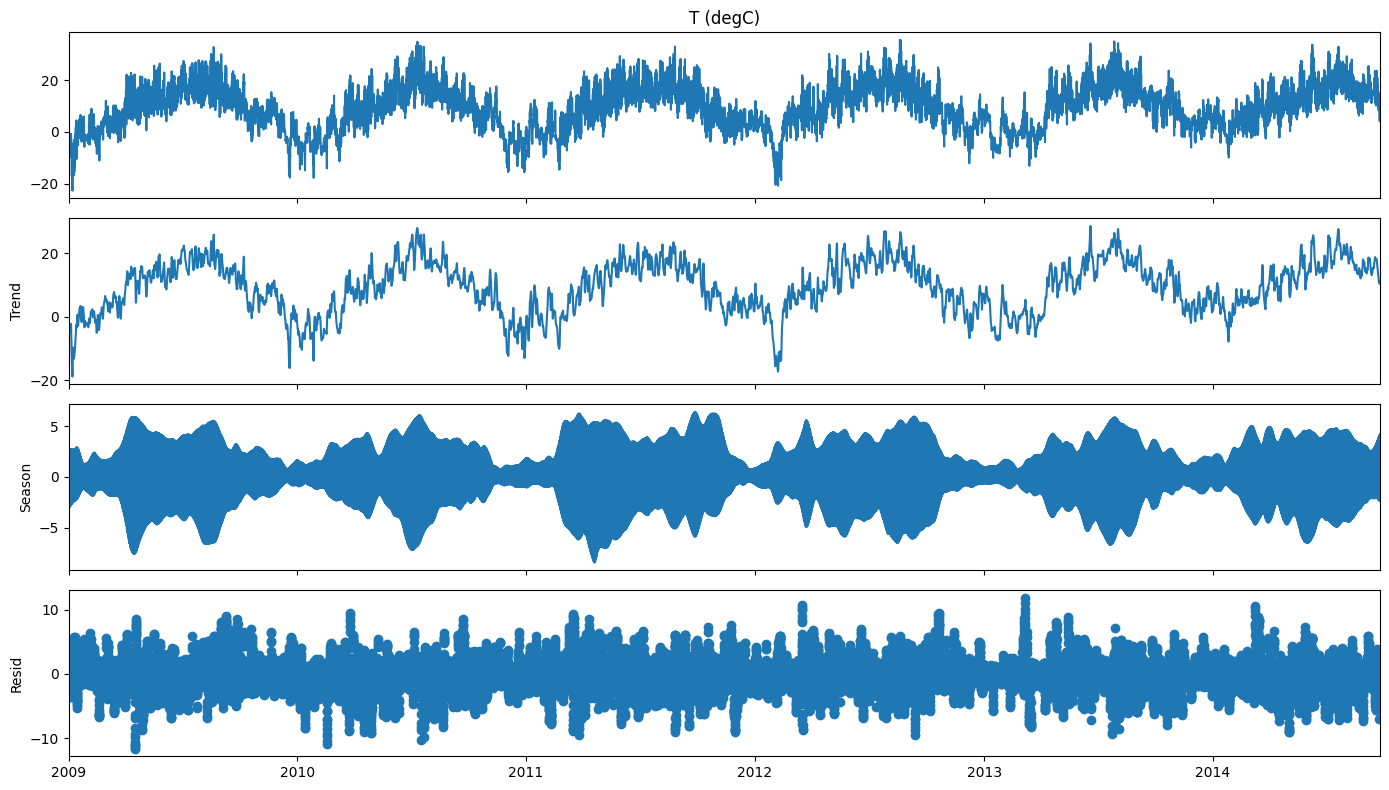

In [7]:
def maior_trecho_continuo(serie):
    observada = serie.dropna().sort_index()
    blocos = observada.index.to_series().diff().ne(pd.Timedelta(hours=1)).cumsum()
    grupos = list(observada.groupby(blocos.to_numpy()))
    return max(grupos, key=lambda par: len(par[1]))[1].asfreq('h')

serie_stl = maior_trecho_continuo(df.loc[df.index < INICIO_TESTE, TARGET_COLUMN])
assert serie_stl.notna().all()
print(f'STL no treino: {serie_stl.index.min()} a {serie_stl.index.max()} ({len(serie_stl):,} horas)')
stl_resultado = calcular_forca_sazonalidade(serie_stl, periodo=SEASONAL_PERIOD)
decomposicao = stl_resultado['decomposicao']
print(f"Força sazonal diária: {stl_resultado['forca_sazonalidade']:.4f}")
print(f"Força de tendência: {stl_resultado['forca_tendencia']:.4f}")
fig = decomposicao.plot(); fig.set_size_inches(14, 8)
plt.tight_layout(); plt.show()

## T05 — Força da sazonalidade e resíduos

A força sazonal indica quanto o componente diário reduz a variância residual. O componente residual é avaliado por média, dispersão e Ljung–Box. A autocorrelação residual indica dependência temporal ainda não explicada pelo modelo e deve ser interpretada em conjunto com o horizonte fixo de uma hora.

In [8]:
# Força sazonal e componente residual
analise_residuos_stl = analisar_componente_residual(decomposicao, lags=24)
print(f"Média do residual: {analise_residuos_stl['media']:.6f}")
print(f"Desvio-padrão do residual: {analise_residuos_stl['desvio_padrao']:.6f}")
display(analise_residuos_stl["autocorrelacao_residual"])

Média do residual: -0.064830
Desvio-padrão do residual: 1.660688


,lb_stat,lb_pvalue
1,42872.998959,0.0
2,73753.473859,0.0
3,93368.126186,0.0
4,104030.418499,0.0
5,108637.517936,0.0
6,109905.840070,0.0
7,109967.094681,0.0
8,110183.229168,0.0
9,111203.311940,0.0
10,113106.206035,0.0


# 3. Features e validação

## T06 — Pipeline de features

Construção do pipeline de features com lags do alvo e das exógenas, janelas móveis, variáveis de calendário e encoding cíclico.

In [9]:
# T06 — geração unificada; lags são calculados na grade completa.
from features_temporais import construir_features_temporais

model_data = construir_features_temporais(
    df, TARGET_COLUMN,
    lags_alvo=TARGET_LAGS,
    lags_exogenas=EXOG_LAGS,
    janelas_moveis=ROLLING_WINDOWS,
    horizonte=HORIZON, frequencia=FREQUENCY, remover_incompletos=True,
)
print(f"Features criadas: {model_data.shape[1] - 1} | observações utilizáveis: {len(model_data):,}")

Features criadas: 30 | observações utilizáveis: 69,537


## T07 — Escalonamento por janela

O Random Forest não exige escalonamento: as árvores usam pontos de corte e são invariantes à escala das variáveis. A separação temporal permanece necessária para evitar que informações do futuro participem do treinamento.

In [10]:
# T07 — Random Forest não precisa de escalonamento; apenas do corte temporal.

train = model_data.loc[model_data.index < INICIO_TESTE]
test = model_data.loc[model_data.index >= INICIO_TESTE]
if train.empty or test.empty or train.index.max() >= test.index.min():
    raise ValueError("Divisão temporal inválida.")
y_train, y_test = train["target"], test["target"]
X_train, X_test = train.drop(columns="target"), test.drop(columns="target")

print(f"Treino: {len(train):,} | teste: {len(test):,}")
print(f"Corte comum: {FIM_TREINO} -> {INICIO_TESTE}")

Treino: 55,752 | teste: 13,785
Corte comum: 2015-05-27 14:00:00 -> 2015-05-27 15:00:00


## T08 — Protocolo de previsão de uma hora

Os hiperparâmetros são escolhidos em três janelas expansivas dentro do treino, cada uma avaliada nos seis meses seguintes. Na avaliação final, a floresta fica fixa: a cada hora entram as observações que já estariam disponíveis até `t-1`. Essa avaliação sequencial com atualização de entradas não realiza retreinamento a cada hora e não representa previsão de todo o teste de uma só vez.

In [11]:
# Janelas de seis meses de calendário, cobrindo os últimos 18 meses do treino.
fim_desenvolvimento = INICIO_TESTE
folds = []
linhas_folds = []
for i in range(N_SPLITS_VALIDACAO):
    inicio_val = fim_desenvolvimento - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i))
    fim_val = fim_desenvolvimento - pd.DateOffset(months=MESES_VALIDACAO * (N_SPLITS_VALIDACAO - i - 1))
    ia = np.flatnonzero(X_train.index < inicio_val)
    iv = np.flatnonzero((X_train.index >= inicio_val) & (X_train.index < fim_val))
    assert len(ia) and len(iv)
    assert X_train.index[ia].max() < X_train.index[iv].min() < INICIO_TESTE
    folds.append((ia, iv))
    linhas_folds.append({'fold': i+1, 'treino_ate': X_train.index[ia].max(),
                         'validacao_inicio': X_train.index[iv].min(),
                         'validacao_fim': X_train.index[iv].max(),
                         'n_treino': len(ia), 'n_validacao': len(iv)})
fold_table = pd.DataFrame(linhas_folds)
display(fold_table)
# Comprova que os lags correspondem às horas originais, mesmo onde há lacunas.
np.testing.assert_allclose(model_data['target_lag_1'], df[TARGET_COLUMN].shift(1).reindex(model_data.index))
np.testing.assert_allclose(model_data['target_lag_24'], df[TARGET_COLUMN].shift(24).reindex(model_data.index))
print('Avaliação final: modelo fixo, entradas atualizadas por hora; horizonte = 1 hora.')

,fold,treino_ate,validacao_inicio,validacao_fim,n_treino,n_validacao
0,1,2013-11-27 14:00:00,2013-11-27 15:00:00,2014-05-27 14:00:00,42831,4344
1,2,2014-05-27 14:00:00,2014-05-27 15:00:00,2014-11-27 14:00:00,47175,4233
2,3,2014-11-27 14:00:00,2014-11-27 15:00:00,2015-05-27 14:00:00,51408,4344


Avaliação final: modelo fixo, entradas atualizadas por hora; horizonte = 1 hora.


# 4. Modelagem Random Forest

## T11 — Busca de hiperparâmetros

Busca aleatória reprodutível: 12 combinações amostradas do espaço de 48 possibilidades, cada uma avaliada nas três janelas temporais. A escolha minimiza o MAE conjunto da validação. É uma busca limitada, não uma garantia de ótimo global. O teste final não participa da seleção.

In [12]:
inicio_grid = time.perf_counter()
parametros = list(ParameterSampler(PARAM_GRID, n_iter=N_CANDIDATOS, random_state=SEED))
resultados_grid, resultados_folds = [], []
for grid_index, params in enumerate(parametros):
    erros = []
    inicio_candidato = time.perf_counter()
    for fold, (ia, iv) in enumerate(folds, start=1):
        modelo_grid = RandomForestRegressor(**params, random_state=SEED, n_jobs=N_JOBS)
        modelo_grid.fit(X_train.iloc[ia], y_train.iloc[ia])
        previsto = modelo_grid.predict(X_train.iloc[iv])
        erros.extend(y_train.iloc[iv].to_numpy() - previsto)
        resultados_folds.append({'candidato': grid_index, 'fold': fold,
            'MAE': mean_absolute_error(y_train.iloc[iv], previsto),
            'MAE_persistencia': mean_absolute_error(y_train.iloc[iv], X_train.iloc[iv]['target_lag_1'])})
    resultados_grid.append({'grid_index': grid_index, **params,
        'MAE_validacao': float(np.abs(erros).mean()),
        'RMSE_validacao': float(np.sqrt(np.mean(np.square(erros)))),
        'tempo_segundos': time.perf_counter()-inicio_candidato})
    print(f'Candidato {grid_index+1}/{len(parametros)}: MAE={resultados_grid[-1]["MAE_validacao"]:.4f} °C')

df_grid = pd.DataFrame(resultados_grid).sort_values('MAE_validacao').reset_index(drop=True)
BEST_PARAMS = parametros[int(df_grid.loc[0, 'grid_index'])].copy()
tempo_grid = time.perf_counter() - inicio_grid
display(df_grid)
print('Parâmetros congelados antes do teste:', BEST_PARAMS)

,grid_index,n_estimators,min_samples_split,min_samples_leaf,max_features,max_depth,MAE_validacao,RMSE_validacao,tempo_segundos
0,3,200,5,2,1.0,NaN,0.395618,0.579855,189.341610
1,1,100,2,2,1.0,NaN,0.396765,0.581235,107.016240
2,5,200,2,1,1.0,NaN,0.398149,0.582409,200.406125
3,7,200,5,2,1.0,10.0,0.411583,0.600900,118.182395
4,6,100,2,1,1.0,10.0,0.413667,0.603270,59.649874
5,9,200,2,1,sqrt,NaN,0.479242,0.680488,41.730267
6,0,200,5,1,sqrt,NaN,0.482247,0.684956,35.871674
7,4,100,2,1,sqrt,NaN,0.483254,0.684554,22.486212
8,2,100,5,1,sqrt,NaN,0.488115,0.691838,27.888709
9,11,200,5,1,sqrt,10.0,0.580279,0.807950,22.563236


Parâmetros congelados antes do teste: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 1.0, 'max_depth': None}


## T12 — Treino final e previsões sequenciais

Ajuste único em todo o treino, com hiperparâmetros congelados. No teste, as features de cada hora usam apenas o passado. Salva também persistência (hora anterior) e previsão sazonal ingênua (mesma hora do dia anterior), nos mesmos timestamps.

As datas da base representam o início da hora. `origem` é o instante de emissão, igual a `data`; `ultima_hora_observada` é o rótulo da hora anterior, já encerrada. O horizonte de uma hora termina em `fim_intervalo_previsto`.

In [13]:
# Modelo congelado no treino; previsões móveis de uma hora no teste.
inicio_walk_forward = time.perf_counter()
modelo_final = RandomForestRegressor(
    **BEST_PARAMS, random_state=SEED, n_jobs=N_JOBS
)
modelo_final.fit(X_train, y_train)
previsto = modelo_final.predict(X_test)
wf = pd.DataFrame({
    "modelo": "Random Forest",
    "origem": X_test.index,
    "ultima_hora_observada": X_test.index - pd.Timedelta(hours=1),
    "fim_intervalo_previsto": X_test.index + pd.Timedelta(hours=1),
    "data": X_test.index,
    "passo": 1,
    "real": y_test.to_numpy(),
    "previsto": previsto,
    "residuo": y_test.to_numpy() - previsto,
})
wf['persistencia'] = X_test['target_lag_1'].to_numpy()
wf['sazonal_24h'] = X_test['target_lag_24'].to_numpy()
pred_treino = modelo_final.predict(X_train)
tempo_walk_forward = time.perf_counter() - inicio_walk_forward
print(f"Previsões de uma hora registradas: {len(wf):,}")

Previsões de uma hora registradas: 13,785


# 5. Avaliação

## T16 — Comparação por MAE

Consolidação do MAE fora da amostra por base e modelo, incluindo número de vitórias e posição média.

,modelo,n,MAE,RMSE,R2,vies_real_menos_previsto,P90_erro_absoluto,MaxAE,ganho_MAE_vs_persistencia_pct
0,Random Forest,13785,0.3951,0.5740,0.9950,0.0223,0.8657,7.3532,42.4569
1,Persistência (1h),13785,0.6865,0.9515,0.9863,-0.0010,1.5220,8.2100,0.0000
2,Sazonal ingênuo (24h),13785,2.5802,3.3774,0.8276,-0.0145,5.5617,15.0550,-275.8324


MAE treino: 0.1634 °C | MAE validação: 0.3956 °C
Busca: 14.16 min | treino final e previsões: 1.25 min


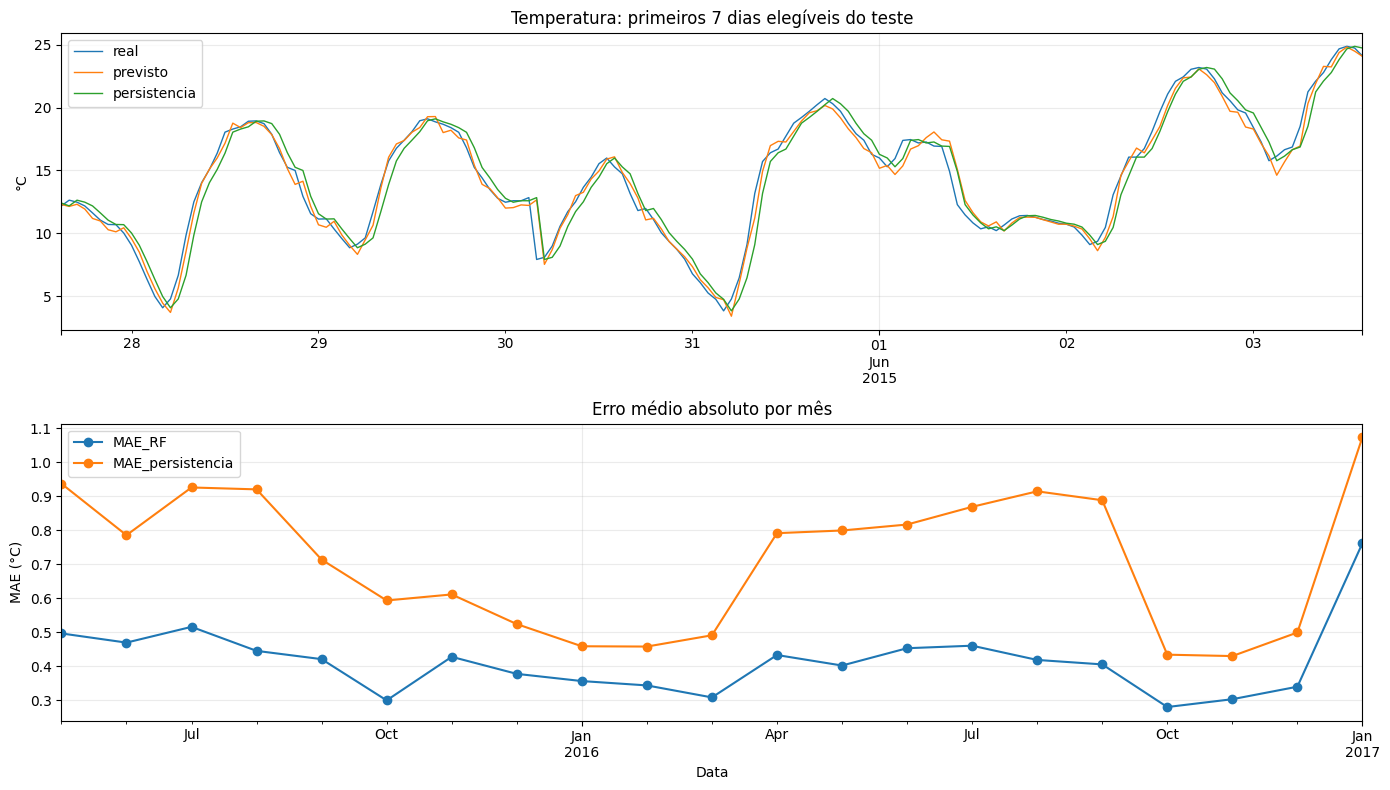

In [14]:
def resumir_metricas(nome, real, previsto):
    erro = np.asarray(real) - np.asarray(previsto)
    return {'modelo': nome, 'n': len(erro), 'MAE': float(np.abs(erro).mean()),
            'RMSE': float(np.sqrt(np.mean(erro**2))), 'R2': float(r2_score(real, previsto)),
            'vies_real_menos_previsto': float(erro.mean()),
            'P90_erro_absoluto': float(np.quantile(np.abs(erro), .9)),
            'MaxAE': float(np.abs(erro).max())}

metricas = pd.DataFrame([
    resumir_metricas('Random Forest', wf['real'], wf['previsto']),
    resumir_metricas('Persistência (1h)', wf['real'], wf['persistencia']),
    resumir_metricas('Sazonal ingênuo (24h)', wf['real'], wf['sazonal_24h']),
])
mae_base = metricas.loc[1, 'MAE']
metricas['ganho_MAE_vs_persistencia_pct'] = 100 * (1 - metricas['MAE'] / mae_base)
display(metricas.round(4))
mae_treino = mean_absolute_error(y_train, pred_treino)
print(f'MAE treino: {mae_treino:.4f} °C | MAE validação: {df_grid.loc[0, "MAE_validacao"]:.4f} °C')
print(f'Busca: {tempo_grid/60:.2f} min | treino final e previsões: {tempo_walk_forward/60:.2f} min')
# Períodos distintos têm dificuldades distintas: diferença treino/teste não prova sozinha overfitting.
mensal = wf.set_index('data').resample('MS').apply({
    'residuo': lambda s: s.abs().mean(), 'real': 'count'})
mensal.columns = ['MAE_RF', 'n']
mensal['MAE_persistencia'] = (wf.set_index('data')['real']-wf.set_index('data')['persistencia']).abs().resample('MS').mean()
print(f'Cobertura do teste: {len(test):,} de {metadados_base["linhas_teste"]:,} horas da grade ' +
      f'({100*len(test)/metadados_base["linhas_teste"]:.2f}%).')

fig, axes = plt.subplots(2, 1, figsize=(14, 8))
janela = wf.set_index('data').loc[lambda x: x.index < x.index.min()+pd.Timedelta(days=7)]
janela[['real','previsto','persistencia']].plot(ax=axes[0], linewidth=1)
axes[0].set(title='Temperatura: primeiros 7 dias elegíveis do teste', ylabel='°C', xlabel='')
mensal[['MAE_RF','MAE_persistencia']].plot(ax=axes[1], marker='o')
axes[1].set(title='Erro médio absoluto por mês', ylabel='MAE (°C)', xlabel='Data')
for ax in axes: ax.grid(alpha=.25)
plt.tight_layout(); plt.show()

## T17 — Diagnóstico dos resíduos

Análise gráfica e estatística dos resíduos com série temporal dos erros, ACF, teste de Ljung-Box e tabela de p-valores.

ACF/Ljung-Box: maior trecho horário contínuo do teste, 12,404 observações, 2015-05-27 15:00:00 a 2016-10-25 10:00:00.


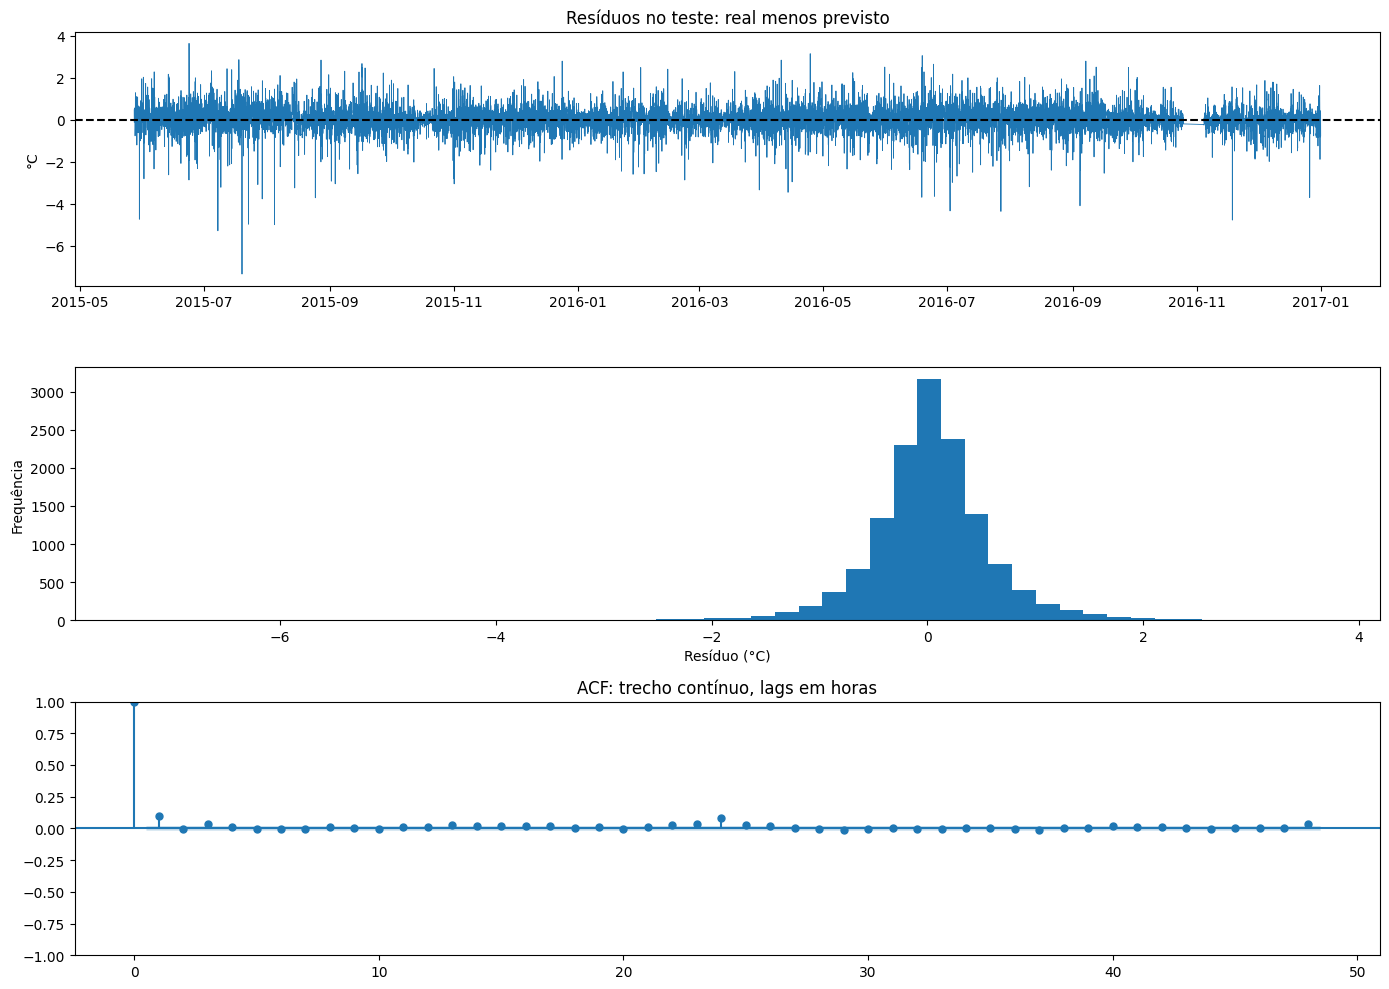

,lb_stat,lb_pvalue
1,111.955710,3.653821e-26
6,127.623474,4.067200e-25
12,134.732426,6.905705e-23
24,266.887110,7.250483e-43
48,307.547925,1.487356e-39


p < 0,05 sugere autocorrelação remanescente; não significa ausência de utilidade preditiva.


In [15]:
residuos = wf.set_index('data')['residuo'].sort_index()
residuos_continuos = maior_trecho_continuo(residuos)
print(f'ACF/Ljung-Box: maior trecho horário contínuo do teste, {len(residuos_continuos):,} observações, '
      f'{residuos_continuos.index.min()} a {residuos_continuos.index.max()}.')
fig, axes = plt.subplots(3, 1, figsize=(14, 10))
axes[0].plot(residuos.index, residuos, linewidth=.6)
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set(title='Resíduos no teste: real menos previsto', ylabel='°C')
axes[1].hist(residuos, bins=50)
axes[1].set(xlabel='Resíduo (°C)', ylabel='Frequência')
plot_acf(residuos_continuos, lags=48, ax=axes[2], title='ACF: trecho contínuo, lags em horas')
plt.tight_layout(); plt.show()
ljung_box = acorr_ljungbox(residuos_continuos, lags=[1,6,12,24,48], return_df=True)
display(ljung_box)
print('p < 0,05 sugere autocorrelação remanescente; não significa ausência de utilidade preditiva.')

## T18 — Importância das features

Cálculo e interpretação da importância das features: permutation importance para modelos de tabela e coeficientes para o SARIMAX.

,feature,aumento_MAE_permutacao,desvio_permutacao,importancia_impureza
0,target_lag_1,9.225165,0.113984,0.988413
1,target_lag_2,0.241382,0.012166,0.002546
25,hora_cos,0.175221,0.009345,0.002915
24,hora_sin,0.037316,0.004040,0.001132
20,target_roll_mean_24,0.026860,0.001895,0.000268
10,rh (%)_lag_1,0.010975,0.001466,0.000374
29,dia_ano_cos,0.009297,0.001994,0.000203
2,target_lag_3,0.009228,0.002316,0.000550
14,wd_sin_lag_1,0.001603,0.001368,0.000294
4,target_lag_12,0.001301,0.001144,0.000193


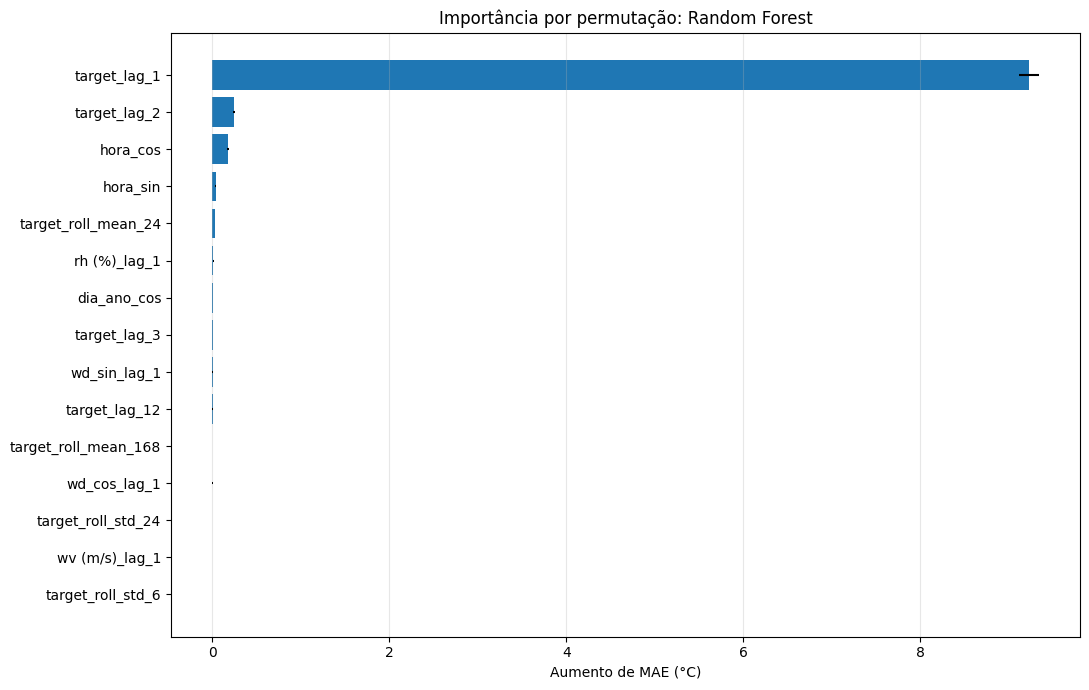

Features correlacionadas podem dividir importância; permutação não mede causalidade.


In [16]:
# Permutação usada apenas para interpretação, sem retunar com o teste.
permutacao = permutation_importance(modelo_final, X_test, y_test,
    scoring='neg_mean_absolute_error', n_repeats=5, max_samples=min(2000,len(X_test)),
    random_state=SEED, n_jobs=1)
importancias = pd.DataFrame({'feature':X_test.columns,
    'aumento_MAE_permutacao':permutacao.importances_mean,
    'desvio_permutacao':permutacao.importances_std,
    'importancia_impureza':modelo_final.feature_importances_,
}).sort_values('aumento_MAE_permutacao',ascending=False)
display(importancias.head(15))
top=importancias.head(15).sort_values('aumento_MAE_permutacao')
fig,ax=plt.subplots(figsize=(11,7))
ax.barh(top['feature'],top['aumento_MAE_permutacao'],xerr=top['desvio_permutacao'])
ax.set(title='Importância por permutação: Random Forest',xlabel='Aumento de MAE (°C)')
ax.grid(axis='x',alpha=.3)
plt.tight_layout();plt.show()
print('Features correlacionadas podem dividir importância; permutação não mede causalidade.')

## Conferência e dispersão dos erros

As previsões, métricas e resíduos são conferidos diretamente em memória. O intervalo do ganho usa bootstrap pareado em blocos de sete dias. A amostra seleciona cerca de 10% das horas elegíveis de cada mês com seed 42; ela faz parte do mesmo teste, não é outro teste independente.

In [ ]:
# Tudo calculado com os objetos deste notebook; nenhum CSV é necessário.
assert wf['data'].is_unique and wf['data'].is_monotonic_increasing
assert (wf['data'] == wf['origem']).all()
np.testing.assert_allclose(wf['real'] - wf['previsto'], wf['residuo'])
for i, coluna in enumerate(['previsto', 'persistencia', 'sazonal_24h']):
    erro = wf['real'] - wf[coluna]
    np.testing.assert_allclose(erro.abs().mean(), metricas.iloc[i]['MAE'])

# Bootstrap pareado de semanas: descreve a incerteza neste teste histórico.
erros_pareados = pd.DataFrame({
    'rf': (wf['real'] - wf['previsto']).abs().to_numpy(),
    'persistencia': (wf['real'] - wf['persistencia']).abs().to_numpy(),
    'n': 1,
}, index=wf['data'])
blocos = erros_pareados.resample('7D').sum().query('n > 0')
rng_bootstrap = np.random.default_rng(SEED)
sorteios = rng_bootstrap.integers(0, len(blocos), size=(2000, len(blocos)))
somas = blocos.to_numpy()[sorteios].sum(axis=1)
ganhos = 100 * (1 - somas[:, 0] / somas[:, 1])
ic_ganho = np.quantile(ganhos, [.025, .975])
print(f'Ganho de MAE sobre persistência: {metricas.loc[0, "ganho_MAE_vs_persistencia_pct"]:.2f}% '
      f'(IC aproximado de 95%: {ic_ganho[0]:.2f}% a {ic_ganho[1]:.2f}%).')

rng_amostra = np.random.default_rng(SEED)
indices_amostra = []
for _, mes in wf.groupby(wf['data'].dt.to_period('M'), sort=True):
    n = max(1, round(len(mes) * .10))
    indices_amostra.extend(rng_amostra.choice(mes.index.to_numpy(), size=n, replace=False))
amostra = wf.loc[sorted(indices_amostra)].copy()

def resumir_erros(recorte, nome, real, previsto):
    erro = np.asarray(real, dtype=float) - np.asarray(previsto, dtype=float)
    return {'recorte': recorte, 'modelo': nome, 'n': len(erro),
            'MAE': np.abs(erro).mean(), 'RMSE': np.sqrt(np.mean(erro**2)),
            'DP_erro': erro.std(ddof=1)}

metricas_recortes = pd.DataFrame([
    resumir_erros('treino', 'Random Forest', y_train, pred_treino),
    *[resumir_erros(rotulo, nome, dados['real'], dados[coluna])
      for rotulo, dados in [('teste completo', wf), ('amostra mensal 10%', amostra)]
      for nome, coluna in [('Random Forest', 'previsto'),
                           ('Persistência (1h)', 'persistencia'),
                           ('Sazonal ingênuo (24h)', 'sazonal_24h')]],
])
display(metricas_recortes.round(4))
print('DP_erro é o desvio padrão de real − previsto. O MAE usa o valor absoluto.')

Ganho de MAE sobre persistência: 42.46% (IC aproximado de 95%: 39.78% a 44.99%).


recorte,modelo,n,MAE,RMSE,desvio_padrao_erro,desvio_padrao_erro_absoluto,vies
treino,Random Forest,55752,0.1634,0.2649,0.2649,0.2085,0.0013
teste completo,Random Forest,13785,0.3951,0.5740,0.5736,0.4164,0.0223
teste completo,Persistência (1h),13785,0.6865,0.9515,0.9515,0.6588,-0.0010
teste completo,Sazonal ingênuo (24h),13785,2.5802,3.3774,3.3774,2.1793,-0.0145
amostra mensal 10%,Random Forest,1376,0.3939,0.5873,0.5864,0.4357,0.0359
amostra mensal 10%,Persistência (1h),1376,0.7117,0.9969,0.9968,0.6983,0.0306
amostra mensal 10%,Sazonal ingênuo (24h),1376,2.6306,3.4516,3.4507,2.2355,0.1242


## Busca de hiperparâmetros e comparação dos recortes

Cada barra mostra o MAE de validação de uma configuração. As hastes representam ±1 desvio padrão dos MAEs nas três janelas de validação, não uma incerteza do teste. Os gráficos seguintes comparam treino, amostra e teste completo usando a mesma floresta.

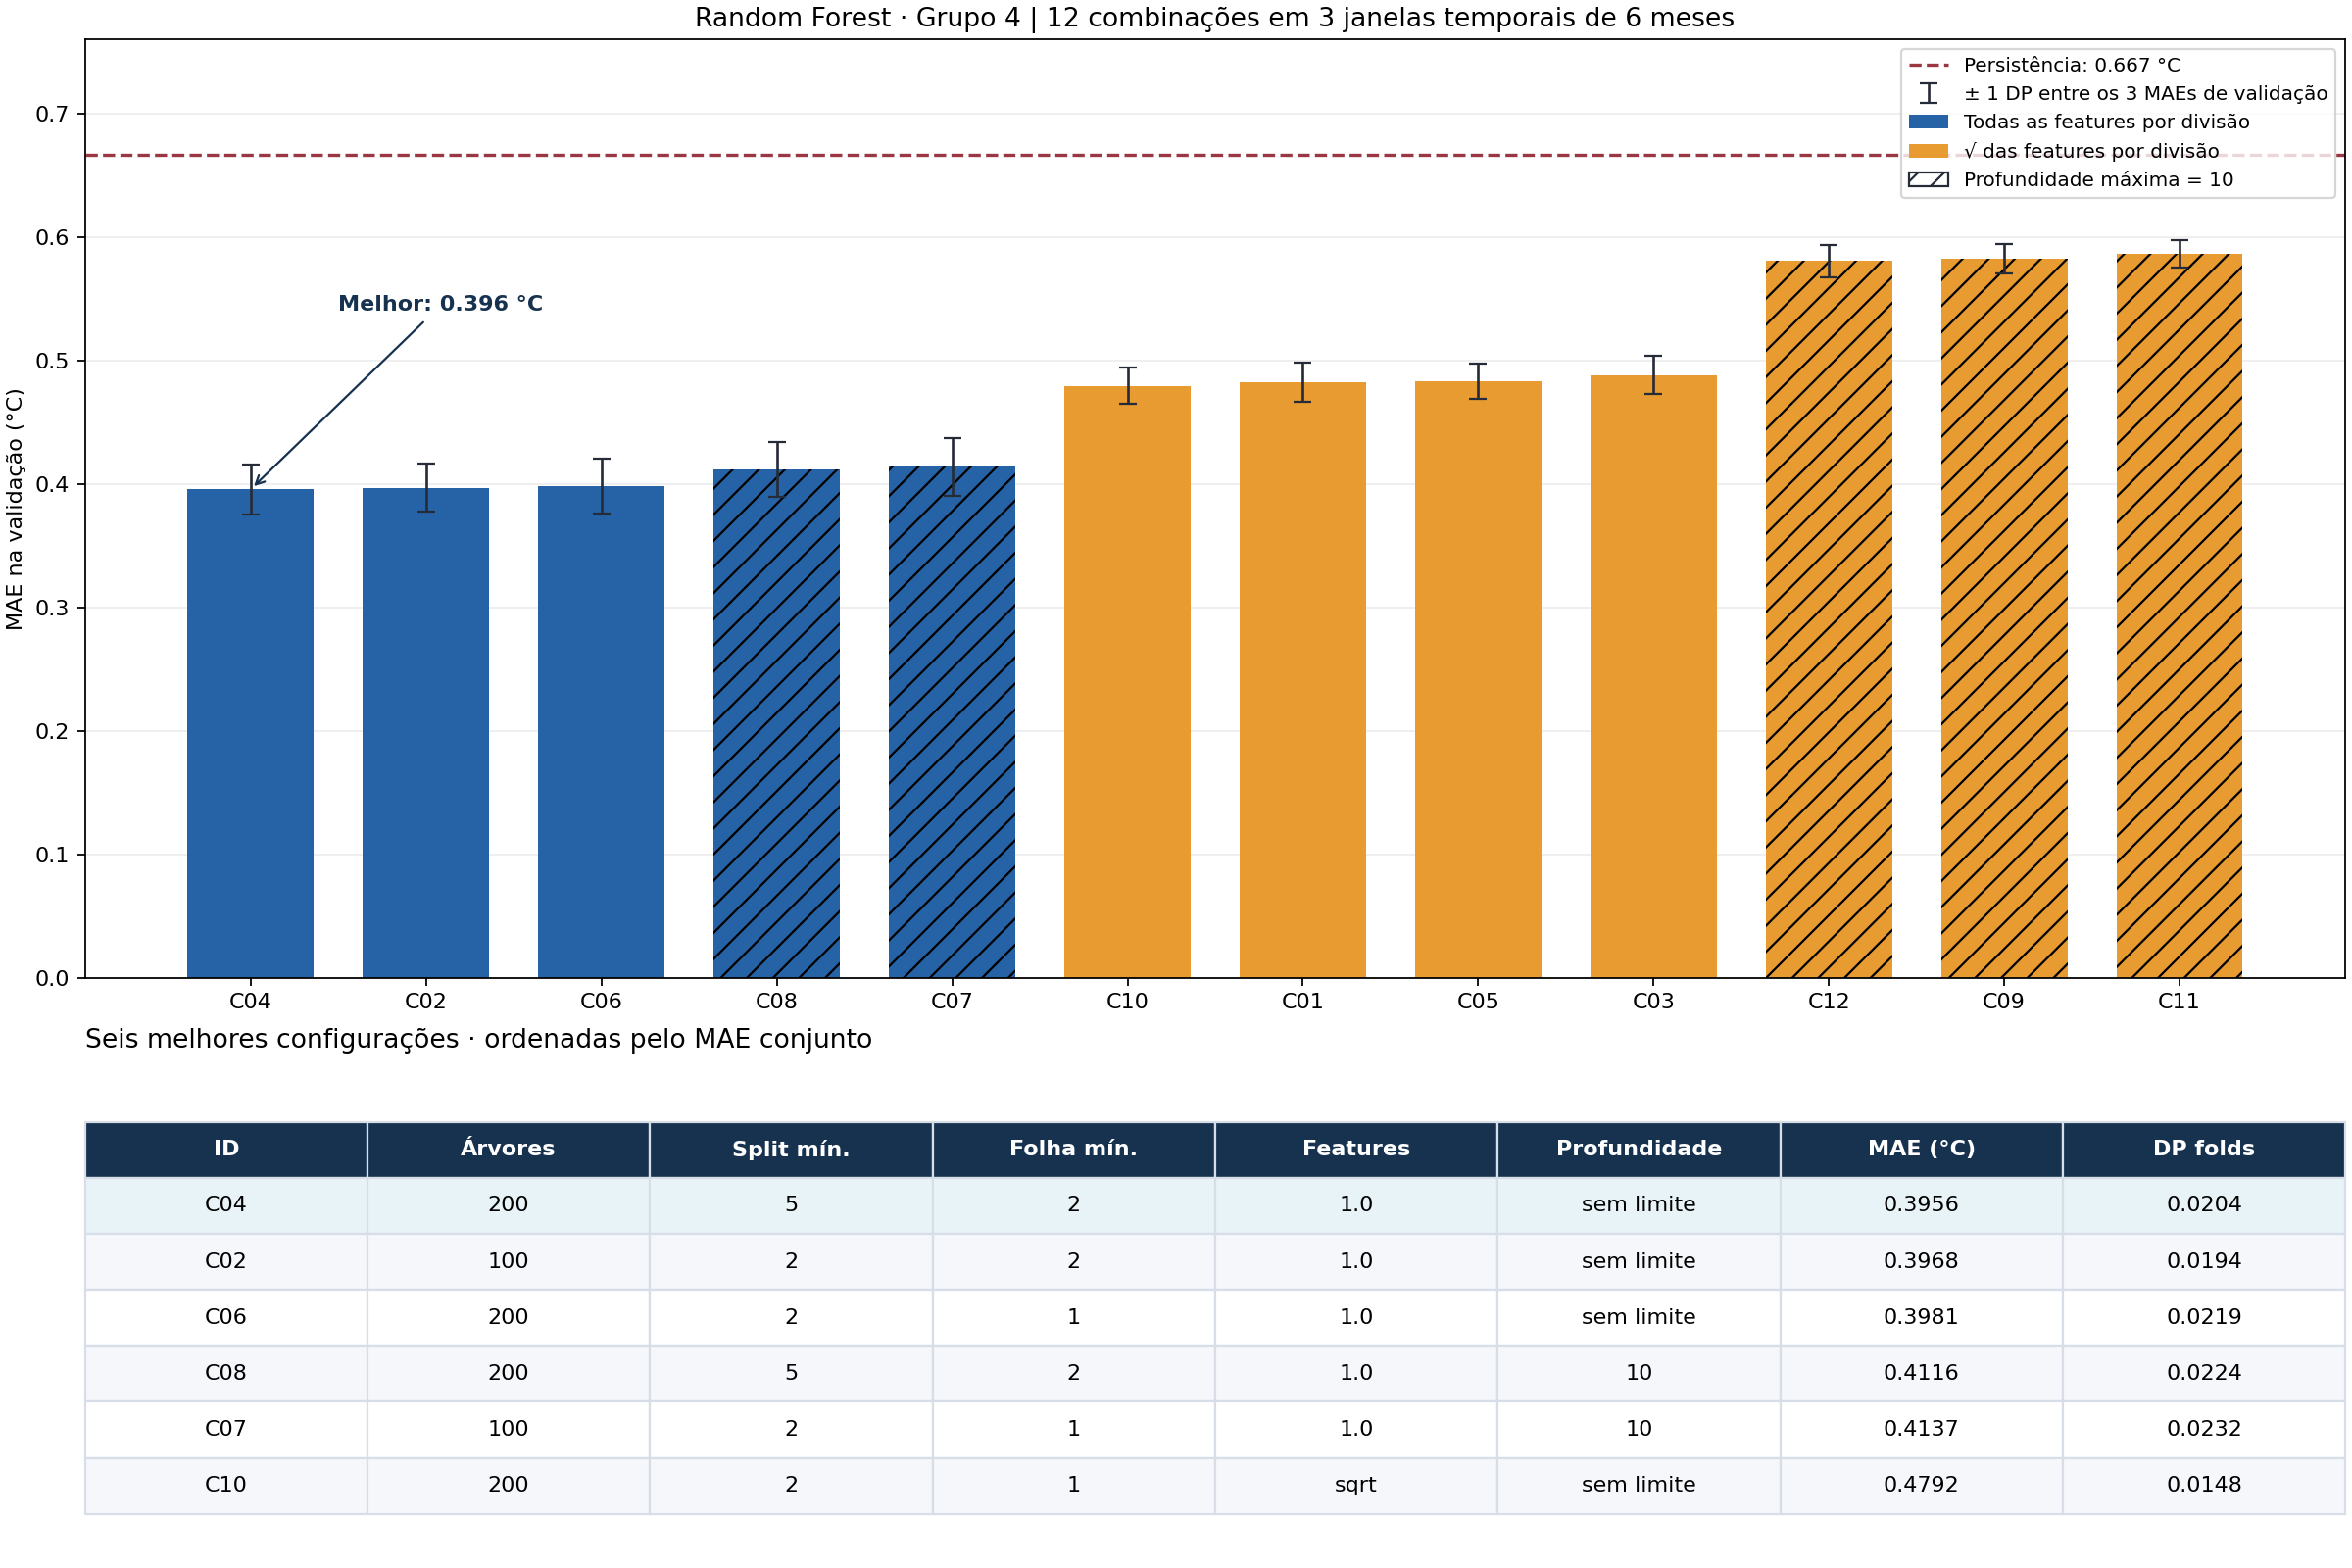

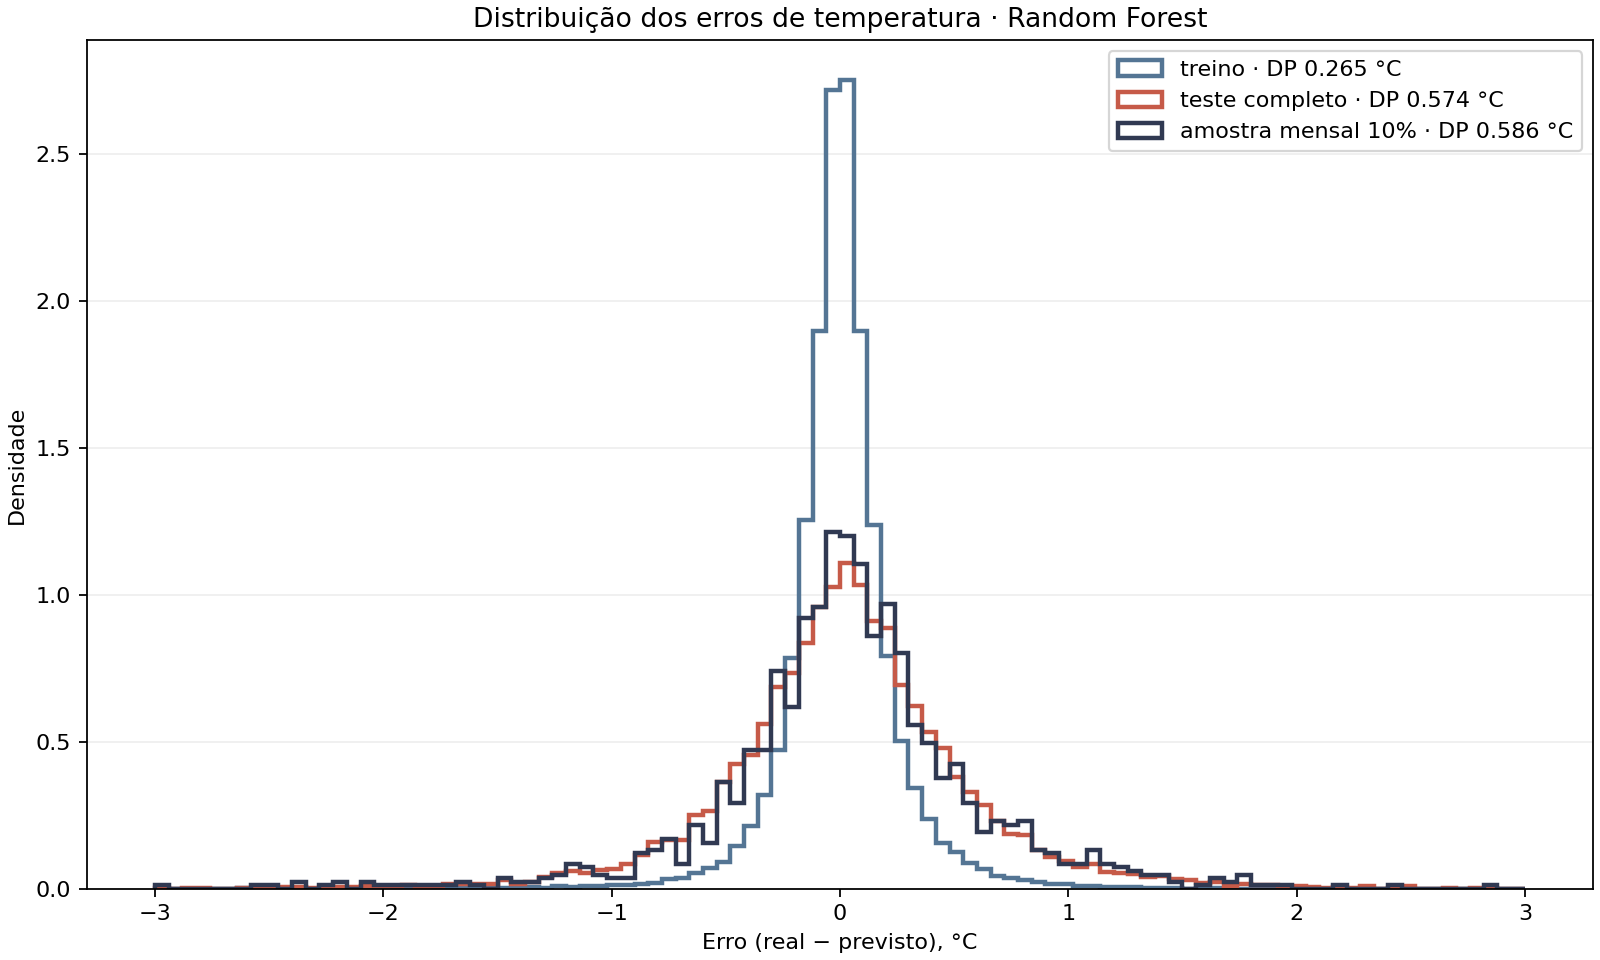

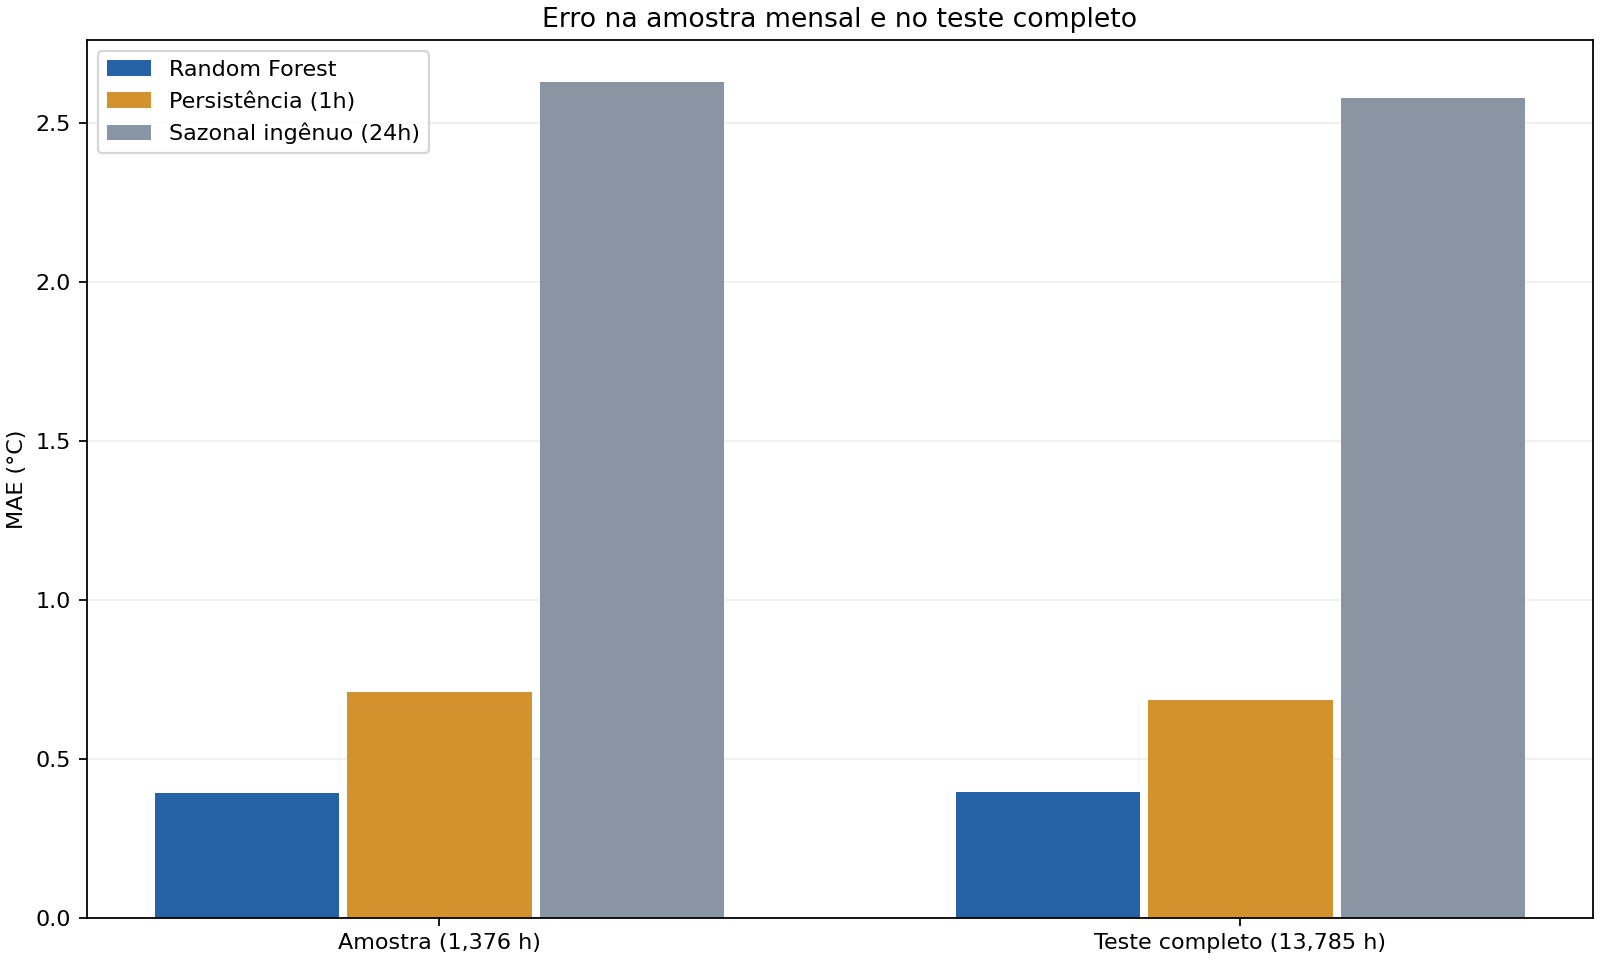

MAE RF no teste inteiro: 0.3951 °C em 13.785 horas.


In [ ]:
folds_resultado = pd.DataFrame(resultados_folds)
busca_plot = df_grid.copy()
busca_plot['DP_folds'] = busca_plot['grid_index'].map(
    folds_resultado.groupby('candidato')['MAE'].std(ddof=1))
busca_plot['id'] = busca_plot['grid_index'].map(lambda i: f'C{i+1:02d}')
fig, ax = plt.subplots(figsize=(13, 5))
cores = ['#2563A6' if str(v) == '1.0' else '#E79B31' for v in busca_plot['max_features']]
ax.bar(busca_plot['id'], busca_plot['MAE_validacao'], color=cores)
ax.errorbar(busca_plot['id'], busca_plot['MAE_validacao'],
            yerr=busca_plot['DP_folds'], fmt='none', color='#252B37', capsize=4)
ax.set(title='Busca de hiperparâmetros · RF 4', ylabel='MAE na validação (°C)',
       xlabel='Configurações ordenadas pelo MAE')
ax.grid(axis='y', alpha=.25)
plt.tight_layout(); plt.show()
display(busca_plot[['id', 'n_estimators', 'min_samples_split', 'min_samples_leaf',
                    'max_features', 'max_depth', 'MAE_validacao', 'DP_folds']].head(6).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for nome, dados, cor in [('treino', pd.DataFrame({'real': y_train, 'previsto': pred_treino}), '#547594'),
                         ('teste completo', wf, '#C65A48'), ('amostra mensal 10%', amostra, '#303952')]:
    erro = np.asarray(dados['real']) - np.asarray(dados['previsto'])
    axes[0].hist(erro, bins=50, alpha=.45, density=True, label=nome, color=cor)
axes[0].set(title='Dispersão dos erros', xlabel='Real − previsto (°C)')
axes[0].legend()
comparacao = metricas_recortes[metricas_recortes['recorte'] != 'treino'].pivot(
    index='modelo', columns='recorte', values='MAE')
comparacao[['amostra mensal 10%', 'teste completo']].plot.bar(ax=axes[1])
axes[1].set(title='MAE por recorte', ylabel='MAE (°C)', xlabel='')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print('Melhor configuração:', BEST_PARAMS)
print(f'MAE RF no teste inteiro: {metricas.loc[0, "MAE"]:.4f} °C em {len(wf):,} horas.')